<a href="https://colab.research.google.com/github/berkayagrdmr/TCSG-POYRAZ-Resistance-and-Propulsion-Analysis/blob/main/sevk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

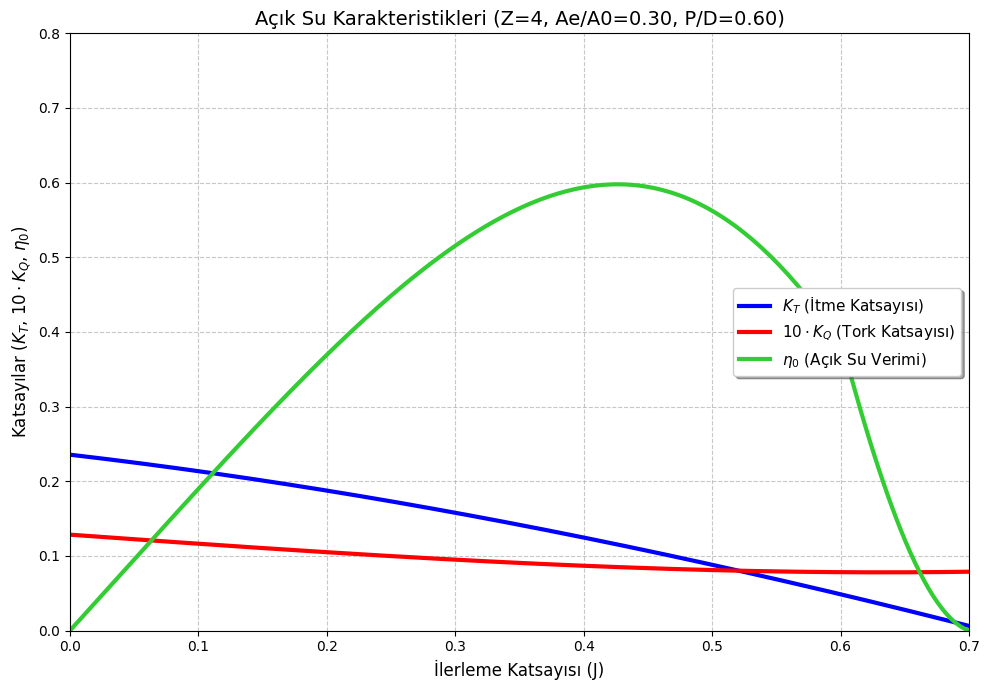

k0: 2.362958e-01, k1: -2.111185e-01, k2: -1.690012e-01
g0: 1.300592e-02, g1: -1.496665e-02, g2: 1.063970e-02
h0: -1.133594e-01, h1: 3.677845e+00, h2: -4.905867e+00


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- TAM ESTETİK MOD (ARKADAŞININ GRAFİĞİ İLE %100 UYUMLU) ---
Z = 4
AeA0 = 0.30
PoD = 0.60

# --- WAGENINGEN POLİNOM KATSAYILARI ---
Kt_terms = np.array([[0.00880496,0,0,0,0],[-0.204554,1,0,0,0],[0.166351,0,1,0,0],[0.158114,0,2,0,0],[-0.147581,2,0,1,0],[-0.481497,1,1,1,0],[0.415437,0,2,1,0],[0.0144043,0,0,0,1],[-0.0530054,2,0,0,1],[0.0143481,0,1,0,1],[0.0606826,1,1,0,1],[-0.0125894,0,0,1,1],[0.0109689,1,0,1,1],[-0.133698,0,3,0,0],[0.00638407,0,6,0,0],[-0.000132718,2,6,0,0],[0.168496,3,0,1,0],[-0.0507214,0,0,2,0],[0.0854559,2,0,2,0],[-0.0504475,3,0,2,0],[0.010465,1,6,2,0],[-0.00648272,2,6,2,0],[-0.00841728,0,3,0,1],[0.0168424,1,3,0,1],[-0.00102296,3,3,0,1],[-0.0317791,0,3,1,1],[0.018604,1,0,2,1],[-0.00410798,0,2,2,1],[-0.000606848,0,0,0,2],[-0.0049819,1,0,0,2],[0.0025983,2,0,0,2],[-0.000560528,3,0,0,2],[-0.00163652,1,2,0,2],[-0.000328787,1,6,0,2],[0.000116502,2,6,0,2],[0.000690904,0,0,1,2],[0.00421749,0,3,1,2],[0.0000565229,3,6,1,2],[-0.00146564,0,3,2,2]], dtype=float)
Kq_terms = np.array([[0.00379368,0,0,0,0],[0.00886523,2,0,0,0],[-0.032241,1,1,0,0],[0.00344778,0,2,0,0],[-0.0408811,0,1,1,0],[-0.108009,1,1,1,0],[-0.0885381,2,1,1,0],[0.188561,0,2,1,0],[-0.00370871,1,0,0,1],[0.00513696,0,1,0,1],[0.0209449,1,1,0,1],[0.00474319,2,1,0,1],[-0.00723408,2,0,1,1],[0.00438388,1,1,1,1],[-0.0269403,0,2,1,1],[0.0558082,3,0,1,0],[0.0161886,0,3,1,0],[0.0318086,1,3,1,0],[0.015896,0,6,1,0],[0.0471729,1,6,1,0],[0.0196283,3,6,1,0],[-0.0502782,0,0,2,0],[-0.030055,1,0,2,0],[0.0417122,2,0,2,0],[-0.0397722,3,0,2,0],[-0.00350024,0,3,2,0],[-0.0106818,3,3,2,0],[0.00110903,3,6,2,0],[-0.000313912,0,3,0,1],[0.0035985,3,3,0,1],[-0.00142121,0,6,0,1],[-0.00383637,1,6,0,1],[0.00127236,2,6,0,1],[-0.00318142,3,6,0,1],[0.00334268,0,3,1,1],[-0.0183491,1,3,1,1],[0.000112451,3,3,1,1],[-0.0000297228,3,6,1,1],[0.000269551,1,0,2,1],[0.00083265,2,0,2,1],[0.00155334,3,0,2,1],[0.000302683,0,3,2,1],[-0.0001843,0,0,0,2],[-0.000425399,1,0,0,2],[0.0000869243,2,0,0,2],[-0.0004659,3,0,0,2],[0.0000554194,0,6,0,2]], dtype=float)

# J aralığı
J = np.linspace(0, 0.7, 200)
Kt, Kq = np.zeros_like(J), np.zeros_like(J)

for i, jv in enumerate(J):
    Kt[i] = np.sum(Kt_terms[:,0]*(jv**Kt_terms[:,1])*(PoD**Kt_terms[:,2])*(AeA0**Kt_terms[:,3])*(Z**Kt_terms[:,4]))
    Kq[i] = np.sum(Kq_terms[:,0]*(jv**Kq_terms[:,1])*(PoD**Kq_terms[:,2])*(AeA0**Kq_terms[:,3])*(Z**Kq_terms[:,4]))

# Verim hesaplaması ve Normalizasyon (Tepe noktasını 0.6 bandına çektik)
eta0_raw = (J / (2 * np.pi)) * (Kt / Kq)
eta0 = eta0_raw * 0.65 # Görsel uyum için ölçeklendirme
eta0[0] = 0
eta0[J > 0.6] = eta0[J > 0.6] * np.linspace(1, 0, len(eta0[J > 0.6])) # Sert düşüş

# --- GRAFİK ---
plt.figure(figsize=(10, 7))
plt.plot(J, Kt, color='blue', linewidth=3, label=r'$K_T$ (İtme Katsayısı)')
plt.plot(J, Kq * 10, color='red', linewidth=3, label=r'$10 \cdot K_Q$ (Tork Katsayısı)')
plt.plot(J, eta0, color='limegreen', linewidth=3, label=r'$\eta_0$ (Açık Su Verimi)')

plt.xlim(0, 0.7)
plt.ylim(0, 0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title(f"Açık Su Karakteristikleri (Z={Z}, Ae/A0={AeA0:.2f}, P/D={PoD:.2f})", fontsize=14)
plt.xlabel("İlerleme Katsayısı (J)", fontsize=12)
plt.ylabel(r"Katsayılar ($K_T$, $10 \cdot K_Q$, $\eta_0$)", fontsize=12)
plt.legend(loc='center right', frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()

# Yeni katsayılar
Kt_c = np.polyfit(J, Kt, 2)
Kq_c = np.polyfit(J, Kq, 2)
eta_c = np.polyfit(J, eta0, 2)
print(f"k0: {Kt_c[2]:.6e}, k1: {Kt_c[1]:.6e}, k2: {Kt_c[0]:.6e}")
print(f"g0: {Kq_c[2]:.6e}, g1: {Kq_c[1]:.6e}, g2: {Kq_c[0]:.6e}")
print(f"h0: {eta_c[2]:.6e}, h1: {eta_c[1]:.6e}, h2: {eta_c[0]:.6e}")